In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
os.chdir('..')
os.getcwd()
import autograd.numpy as anp
import numpy as np
from sazz.samplers.boomerang_sampler.BoomerangSampler import BoomerangSampler
# ============================================================

def simulate_logistic_regression(n=300, p=5, seed=1):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, p))
    beta_true = np.array([2.0, -1.5, 0.5, 0.0, 0.0])[:p]
    if len(beta_true) < p:
        beta_true = np.concatenate([beta_true, np.zeros(p - len(beta_true))])

    logits = X @ beta_true
    probs = 1.0 / (1.0 + np.exp(-logits))
    y = rng.binomial(1, probs, size=n)
    return X, y, beta_true

# ============================================================
# Negative log posterior targets E(beta)
# ============================================================

def E_log_reg(X, y, tau=2.0):
    """
    Bayesian logistic regression with:
        y_i | beta ~ Bernoulli(sigmoid(x_i^T beta))
        beta ~ N(0, tau^2 I)

    Returns E(beta) = negative log posterior up to additive constant.
    """
    X = anp.array(X)
    y = anp.array(y)

    def E(beta):
        eta = X @ beta
        # stable log-likelihood:
        # - sum [ y*eta - log(1+exp(eta)) ]
        nll = anp.sum(anp.logaddexp(0.0, eta) - y * eta)
        nprior = 0.5 / tau**2 * anp.sum(beta**2)
        return nll + nprior

    return E

def gradE_log_reg(X, y, tau=2.0):
    X = anp.array(X)
    y = anp.array(y)

    def gradE(beta):
        eta = X @ beta
        grad_nll = X.T @ (sigmoid(eta) - y)
        grad_prior = beta/tau**2
        return grad_nll + grad_prior
    
    return gradE

def sigmoid(x):
    return np.exp(x) / (1 + np.exp(x))

In [2]:
# Linear regression
n, p = 200, 5
X_log_reg, y_log_reg, beta_true_log_reg = simulate_logistic_regression(n=n, p=p, seed=1)
E = E_log_reg(X_log_reg, y_log_reg, tau=1.0)
gradE = gradE_log_reg(X_log_reg, y_log_reg, tau=1.0)

In [3]:
from autograd import grad
def nll_2dgaussian():
    def E(beta):
        return 0.5 * anp.dot(beta, beta)
    return E

E_gauss = nll_2dgaussian()          
gradE_gauss = grad(E_gauss)          

def nll_banana():
    def E(beta):
        # banana-shaped: twist the second coordinate
        return 0.5 * (beta[0]**2 + (beta[1] - beta[0]**2)**2)
    return E

E_banana = nll_banana()
gradE_banana = grad(E_banana)

In [4]:
N=5000
sampler_log_reg = BoomerangSampler(E=E, N=N, D=p, grad_target=gradE)
sampler_log_reg.preprocess(method="diagonal")

In [5]:
sampler_log_reg.sample_auto(diagnostics=True)

Boomerang time: 100%|█████████▉| 4999/5000 [00:24<00:00, 207.66iter/s, time=1002.408]


=== Sampler Diagnostics ===
Total gradient evals: 1540223
Grad evals per skeleton point: 308.0

=== Thinning Diagnostics ===
Rate evals per Brent call: 21.8 mean, 37 max
Accept/Reject: 4903/65566

=== Event-type breakdown ===
  bounce    : 70469 events, mean horizon=0.9743
  no_event  :   194 events, mean horizon=0.0931
  refresh   :    96 events, mean horizon=0.0000

=== Timing ===
Mean wall-seconds per iteration: 0.000339
Total wall-seconds: 24.01

Time passed: 1002.4078332763866


In [6]:
tau = 1.0
gamma_prior = 0.6
kappa = (gamma_prior / (1 - gamma_prior)) / np.sqrt(2 * np.pi * tau**2)
from sazz.samplers.boomerang_sampler.StickyBoomerangSampler import StickyBoomerangSampler
sampler_sticky_log_reg = StickyBoomerangSampler(E=E, N=N, D=p, grad_target=gradE, kappa=kappa)
sampler_sticky_log_reg.preprocess(method="diagonal")

In [7]:
sampler_sticky_log_reg.sample_auto(diagnostics=True)

Sticky Boomerang time: 100%|█████████▉| 4999/5000 [00:04<00:00, 1036.19iter/s, time=7796.888]


=== Sampler Diagnostics ===
Total gradient evals: 285566
Grad evals per skeleton point: 57.1
Mean sparsity (fraction frozen): 0.348
Max simultaneous frozen: 3 / 5

=== Thinning Diagnostics ===
Rate evals per Brent call: 22.2 mean, 41 max
Accept/Reject: 1948/2127

=== Event-type breakdown ===
  bounce    :  4075 events, mean horizon=0.9430
  freeze    :  1132 events, mean horizon=0.4326
  thaw      :  1130 events, mean horizon=0.4216
  refresh   :   789 events, mean horizon=0.0000

=== Timing ===
Mean wall-seconds per iteration: 0.000371
Total wall-seconds: 4.77

Time passed: 7796.888383134577


In [8]:
from sazz.samplers.boomerang_sampler.StickyBoomerangSampler_pli import StickyBoomerangSampler_pli
sampler_sticky_log_reg_pli = StickyBoomerangSampler_pli(E=E, N=N, D=p, grad_target=gradE, kappa=kappa)
sampler_sticky_log_reg_pli.preprocess(method="diagonal")

In [9]:
sampler_sticky_log_reg_pli.sample_auto()

Sticky Boomerang PLI time: 100%|█████████▉| 4999/5000 [00:00<00:00, 13077.48iter/s, time=11007.189]


=== Sampler Diagnostics ===
Total gradient evals: 11645
Grad evals per skeleton point: 2.3
Mean sparsity (fraction frozen): 0.334
Max simultaneous frozen: 3 / 5

=== Thinning Diagnostics (PLI) ===
Bound violations: 14 across 14 calls
Max ratio: 3.5827
Rate evals per call: 1.9 mean, 7 max
Proposals per call: 0.2 mean, 4 max
Accepted bounces: 532

=== Event-type breakdown ===
  bounce    :   532 events, mean horizon=2.7929
  freeze    :  1691 events, mean horizon=1.9246
  thaw      :  1688 events, mean horizon=2.7200
  refresh   :  1088 events, mean horizon=0.0000

=== Timing ===
Mean wall-seconds per iteration: 0.000064
Total wall-seconds: 0.46

Time passed: 11007.188564967142


In [10]:
from sazz.samplers.boomerang_sampler.utils import resample_sticky_pdmp_path

def resample_pdmp_path(sampler, n_samples=4000):
    t_sk = sampler.Time
    x_sk = sampler.Position
    v_sk = sampler.Velocity

    t_grid = np.linspace(0.0, t_sk[-1], n_samples)
    idx = np.searchsorted(t_sk, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(t_sk) - 2)

    x_res = np.empty((n_samples, x_sk.shape[1]))
    for j, tg in enumerate(t_grid):
        i = idx[j]
        dt = tg - t_sk[i]
        x_res[j], _ = sampler.trajectory(dt, x_sk[i], v_sk[i])  # (t, x, v) not (x, v, t)

    return t_grid, x_res

In [11]:
t, x = resample_pdmp_path(sampler_log_reg, n_samples=50000)
t_sticky, x_sticky = resample_sticky_pdmp_path(sampler_sticky_log_reg, n_samples=50000)
t_pli, x_pli = resample_sticky_pdmp_path(sampler_sticky_log_reg_pli, n_samples=50000)

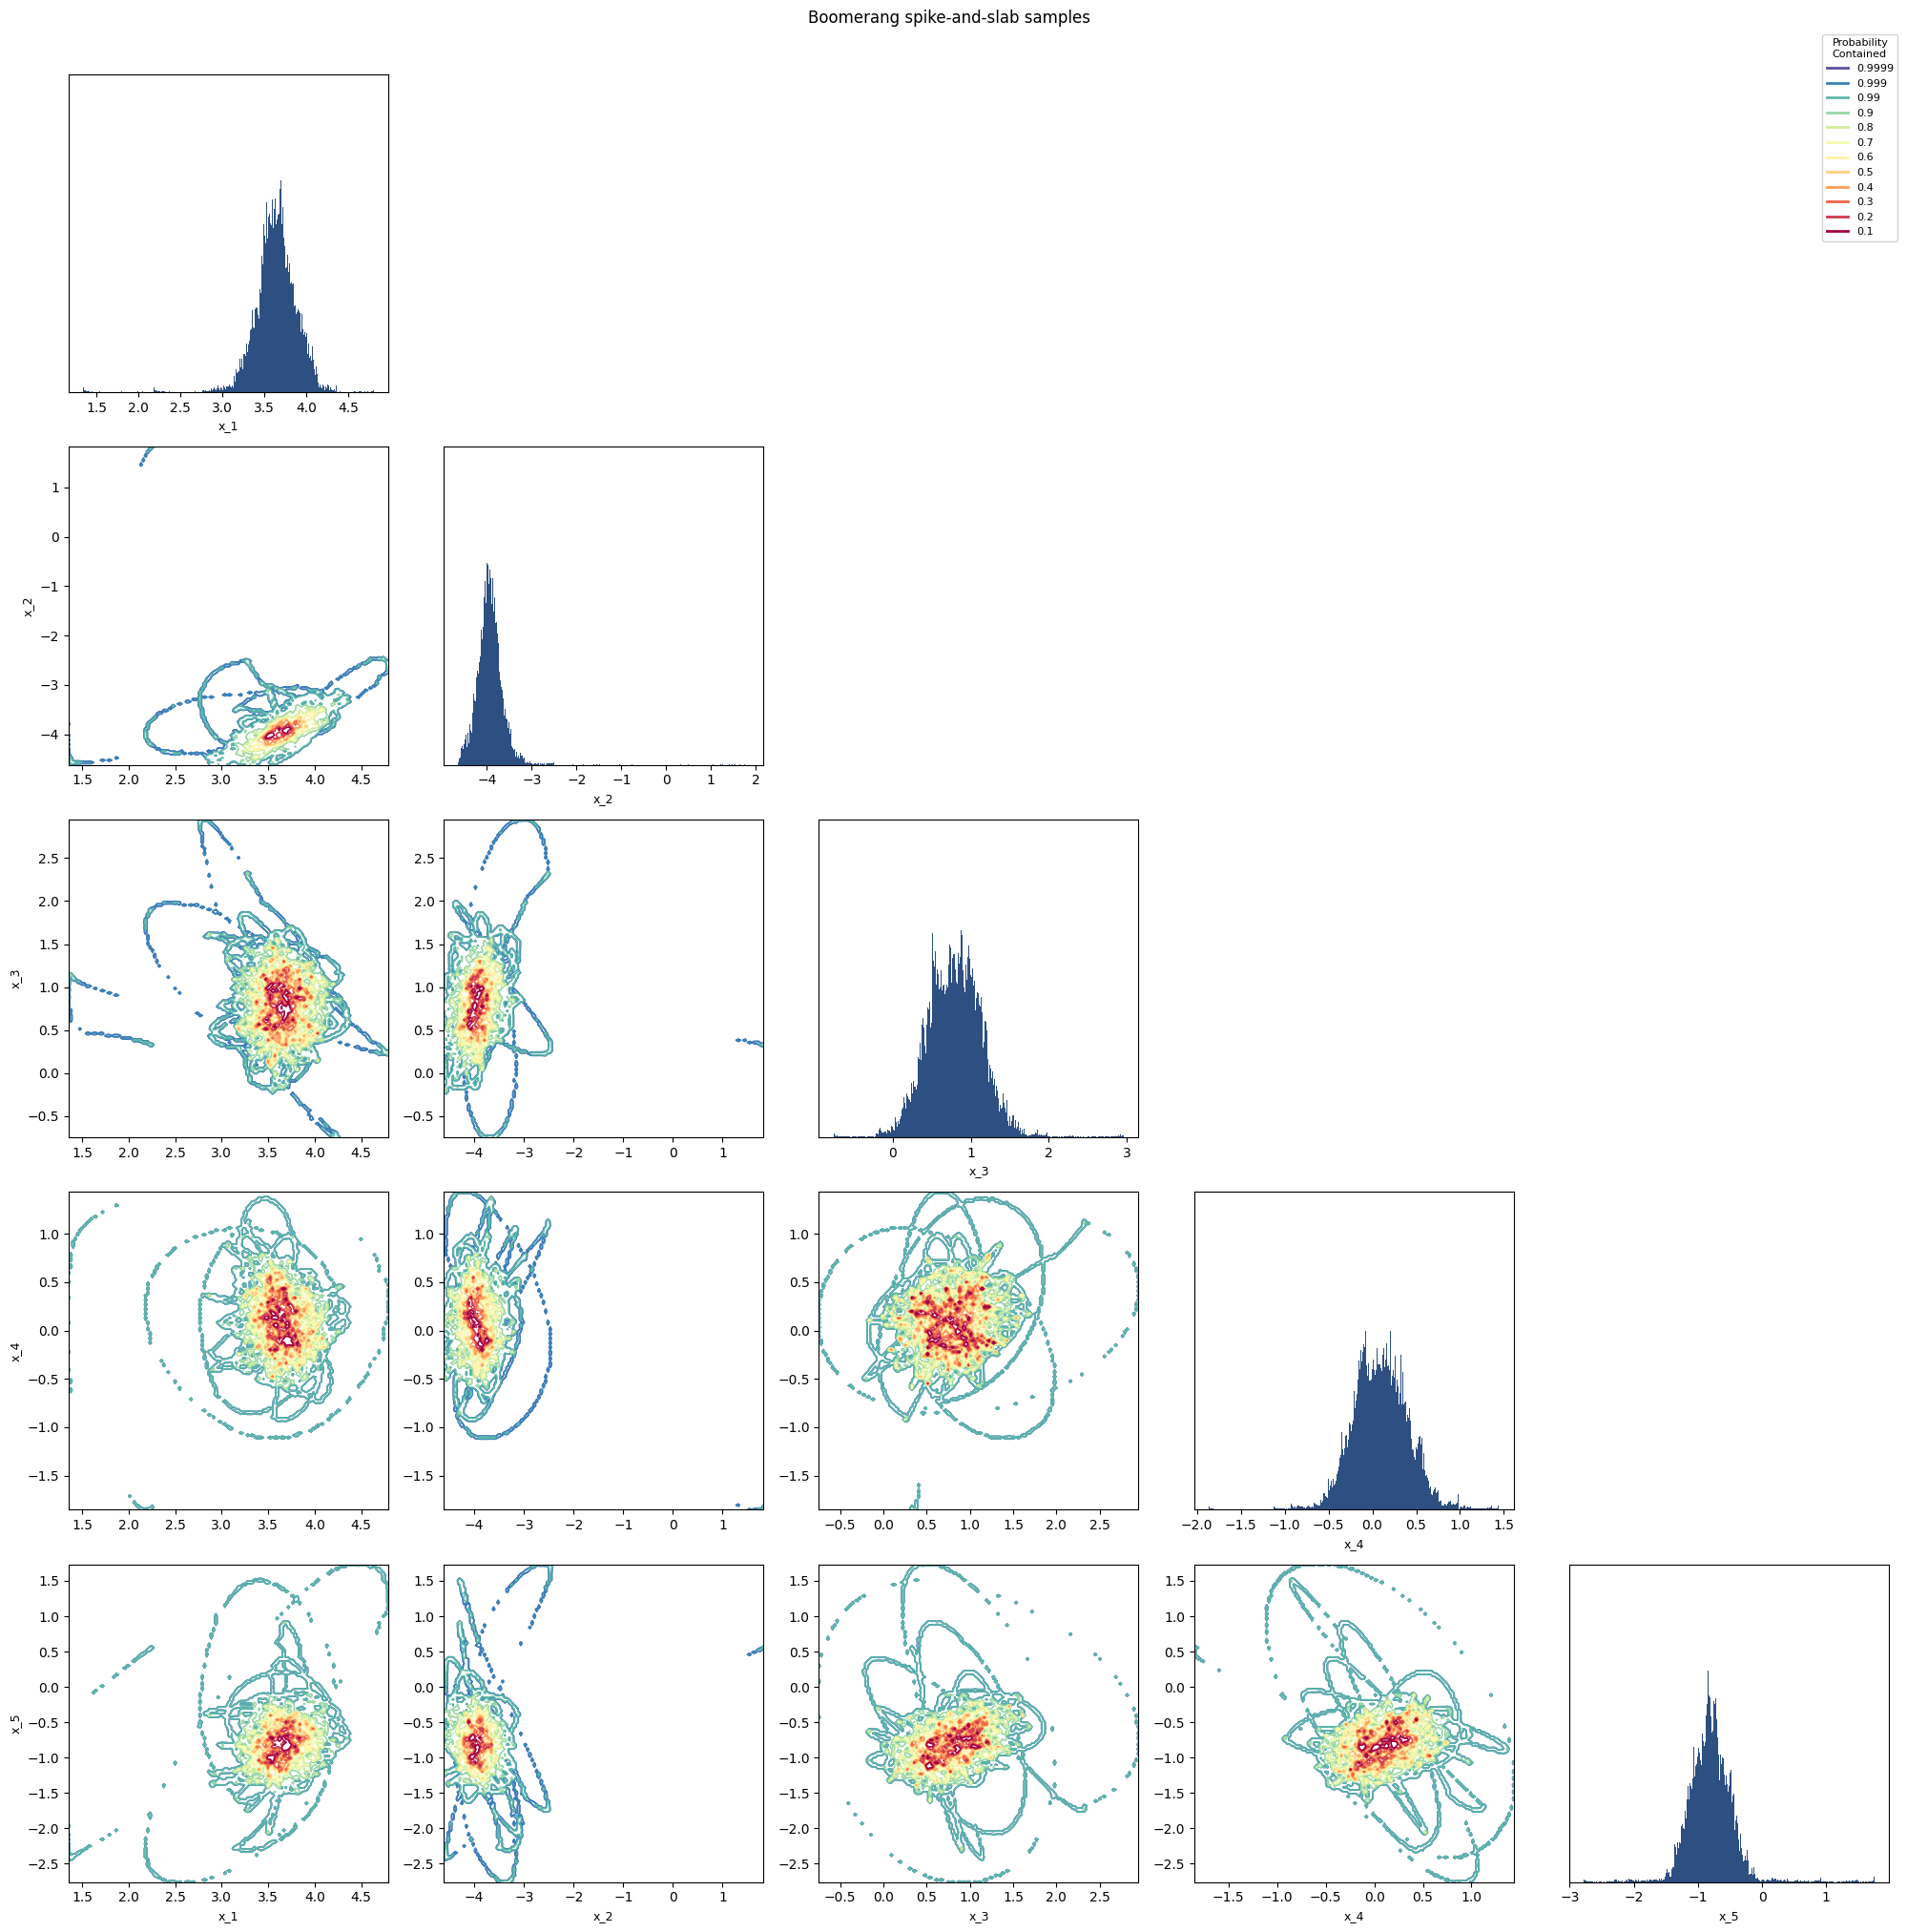

In [12]:
from Filippo_plotting.mcmc_plots import better_pairs

# ── Plug in your own samples here ─────────────────────────────────────────────
variable_names_ss = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']   # optional

fig, axes = better_pairs(
    x[:, :5],
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_ss,
    title='Boomerang spike-and-slab samples',
)
plt.show()

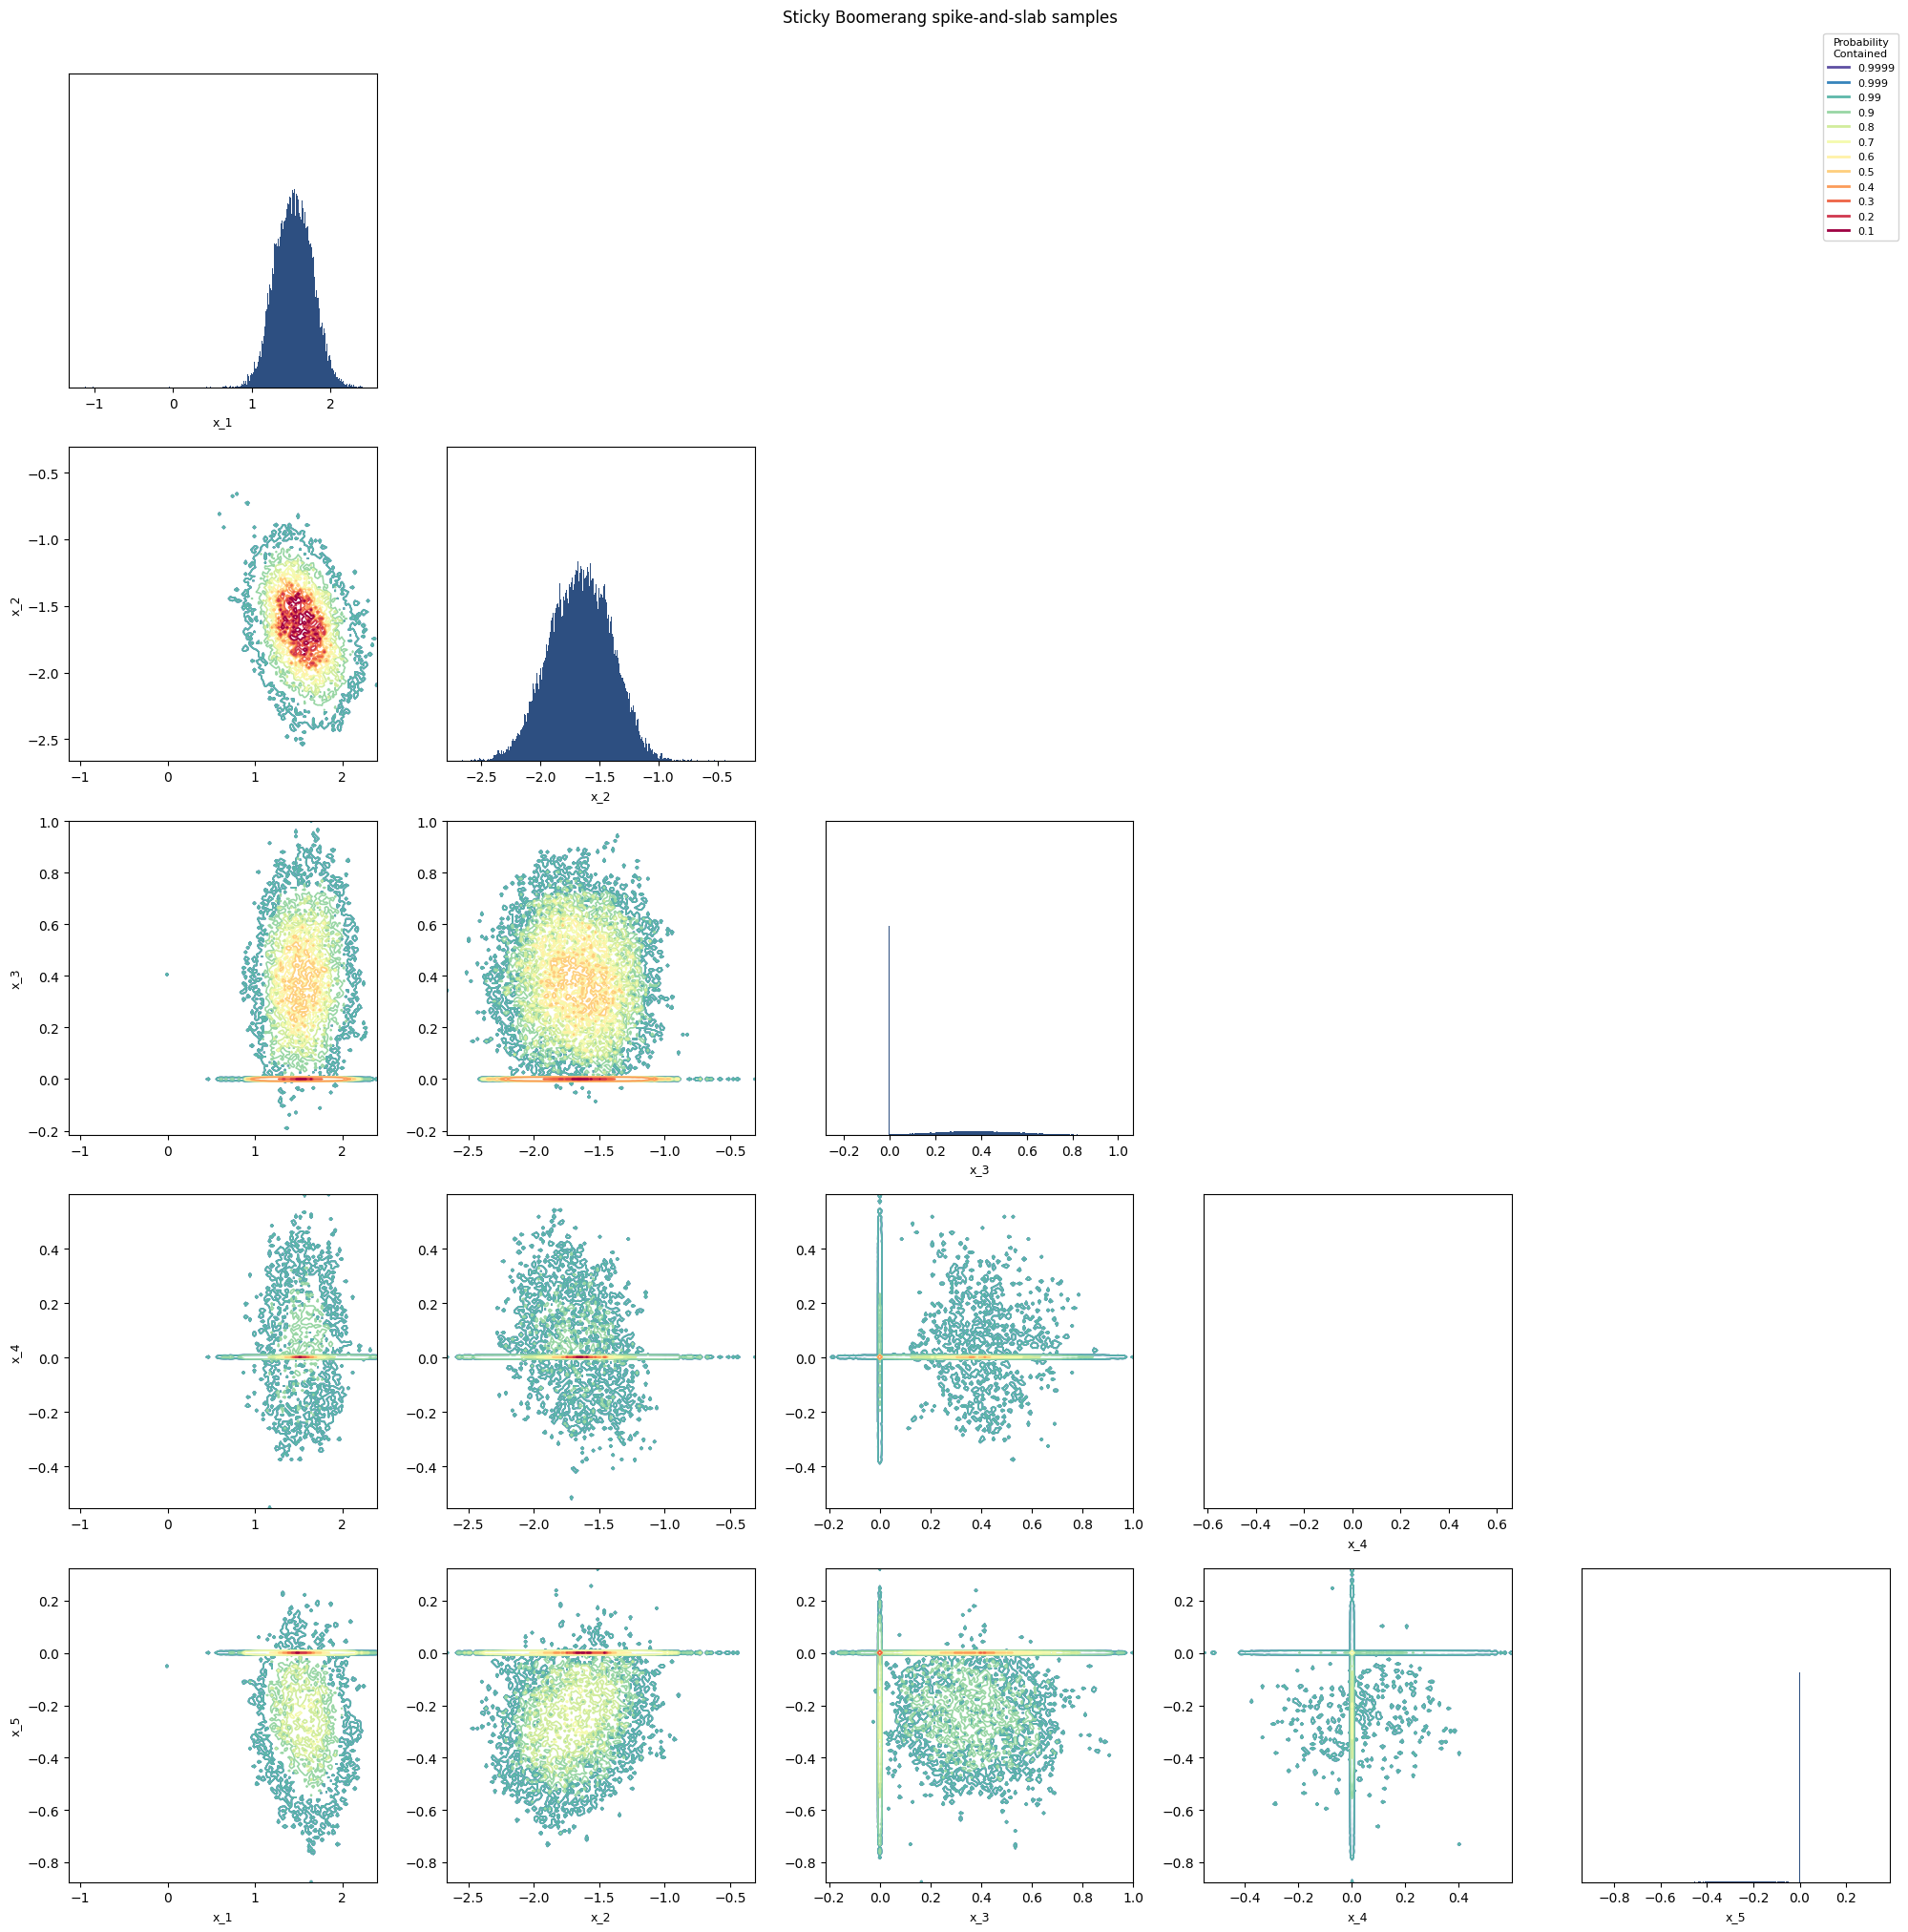

In [13]:
fig, axes = better_pairs(
    x_sticky[:, :5],
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_ss,
    title='Sticky Boomerang spike-and-slab samples',
)
plt.show()

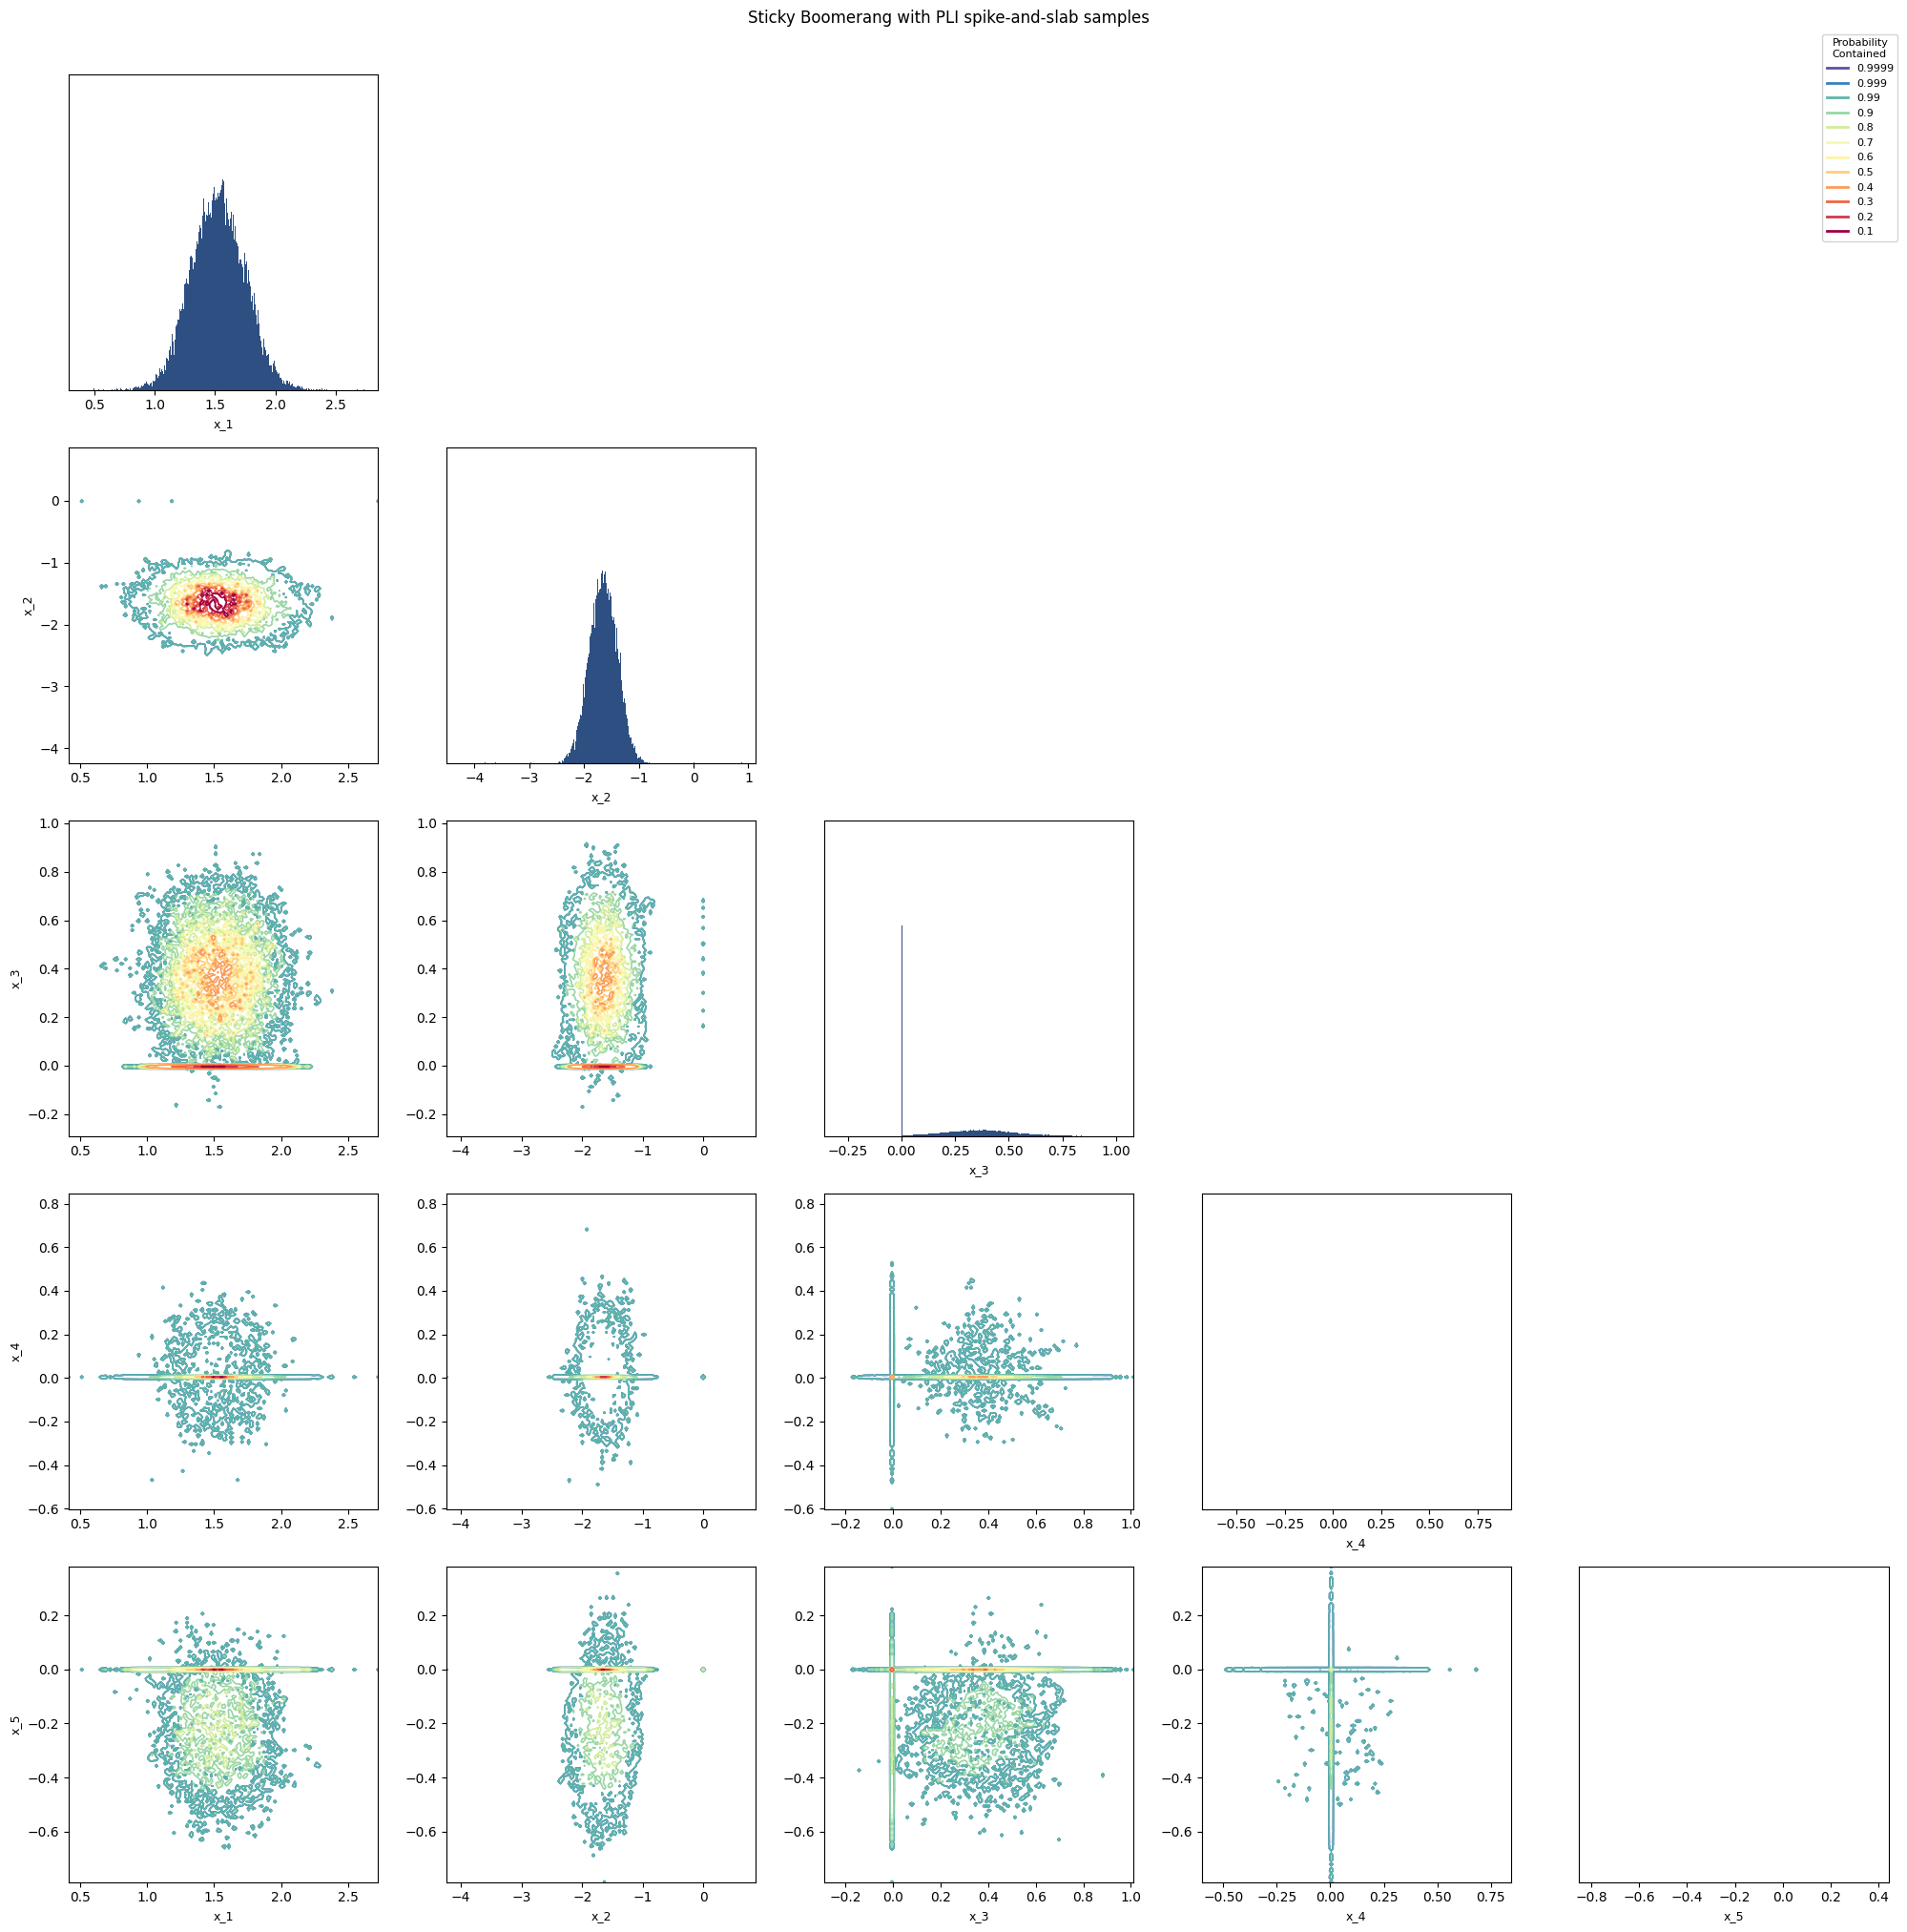

In [14]:
fig, axes = better_pairs(
    x_pli[:, :5],
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_ss,
    title='Sticky Boomerang with PLI spike-and-slab samples',
)
plt.show()

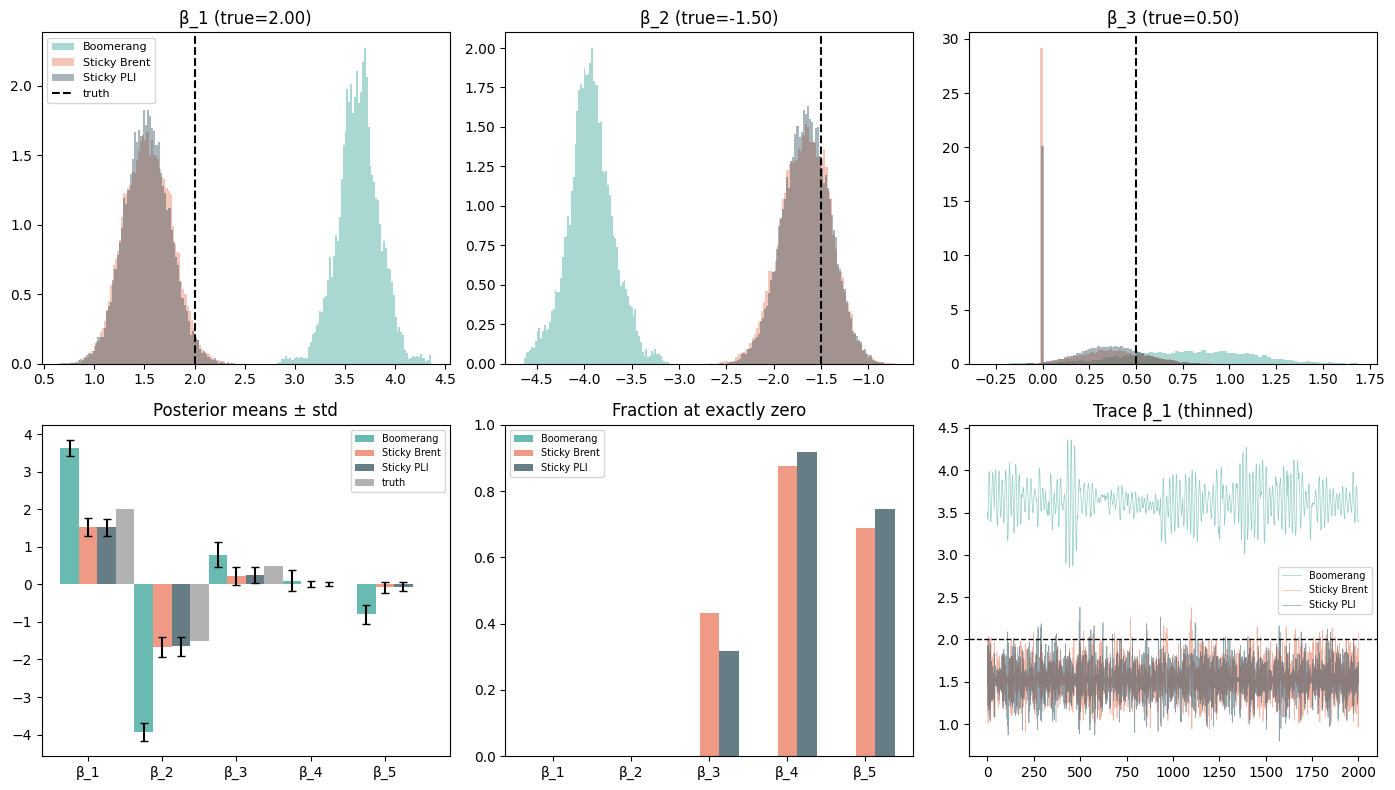

In [15]:
def compare_samplers(samples_dict, beta_true, burn_frac=0.2):
    """
    samples_dict: {'label': x_array} where x_array is (n_samples, d)
    beta_true: ground truth coefficients
    """
    import numpy as np
    import matplotlib.pyplot as plt

    d = beta_true.shape[0]
    labels = list(samples_dict.keys())
    colors = {'Boomerang': '#2a9d8f', 'Sticky Brent': '#e76f51', 'Sticky PLI': '#264653'}

    # Burn-in
    burned = {}
    for k, x in samples_dict.items():
        n_burn = int(burn_frac * x.shape[0])
        burned[k] = x[n_burn:]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    # --- Row 1: marginal densities for first 3 coordinates ---
    for j in range(3):
        ax = axes[0, j]
        for k in labels:
            ax.hist(burned[k][:, j], bins=80, density=True, alpha=0.4,
                    label=k, color=colors[k])
        ax.axvline(beta_true[j], color='k', ls='--', lw=1.5, label='truth')
        ax.set_title(f'β_{j+1} (true={beta_true[j]:.2f})')
        if j == 0:
            ax.legend(fontsize=8)

    # --- Row 2 left: posterior means vs truth ---
    ax = axes[1, 0]
    width = 0.25
    x_pos = np.arange(d)
    for i, k in enumerate(labels):
        means = burned[k].mean(axis=0)
        stds = burned[k].std(axis=0)
        ax.bar(x_pos + i * width, means, width, yerr=stds,
               label=k, color=colors[k], alpha=0.7, capsize=3)
    ax.bar(x_pos + len(labels) * width, beta_true, width,
           label='truth', color='k', alpha=0.3)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'β_{j+1}' for j in range(d)])
    ax.set_title('Posterior means ± std')
    ax.legend(fontsize=7)

    # --- Row 2 middle: sparsity (fraction of exact zeros) ---
    ax = axes[1, 1]
    for i, k in enumerate(labels):
        zero_frac = (burned[k] == 0.0).mean(axis=0)
        ax.bar(x_pos + i * width, zero_frac, width,
               label=k, color=colors[k], alpha=0.7)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f'β_{j+1}' for j in range(d)])
    ax.set_title('Fraction at exactly zero')
    ax.set_ylim(0, 1)
    if 'Sticky' in labels[1]:
        ax.legend(fontsize=7)

    # --- Row 2 right: trace of β_1 ---
    ax = axes[1, 2]
    for k in labels:
        thin = max(1, burned[k].shape[0] // 2000)
        ax.plot(burned[k][::thin, 0], alpha=0.5, label=k, color=colors[k], lw=0.5)
    ax.axhline(beta_true[0], color='k', ls='--', lw=1)
    ax.set_title('Trace β_1 (thinned)')
    ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


compare_samplers(
    {'Boomerang': x, 'Sticky Brent': x_sticky, 'Sticky PLI': x_pli},
    beta_true_log_reg,
)

In [16]:
def bayesian_predictive_eval(samples_dict, X_train, y_train, beta_true,
                              n_test=500, seed=99, burn_frac=0.2, n_bins=10):
    """
    Bayesian predictive evaluation: RMSE, accuracy, NLL, ECE, coverage.
    
    Parameters
    ----------
    samples_dict : dict of {label: array (n_samples, d)}
    X_train, y_train : training data (for reference)
    beta_true : true coefficients used for data generation
    n_test : size of held-out test set
    seed : random seed for test set generation
    burn_frac : fraction of samples to discard as burn-in
    n_bins : number of bins for ECE calculation
    """
    import numpy as np

    # --- Generate test set from true model ---
    rng = np.random.default_rng(seed)
    p = beta_true.shape[0]
    X_test = rng.normal(size=(n_test, p))
    logits_true = X_test @ beta_true
    probs_true = 1.0 / (1.0 + np.exp(-logits_true))
    y_test = rng.binomial(1, probs_true, size=n_test)

    results = {}

    for label, samples in samples_dict.items():
        n_burn = int(burn_frac * samples.shape[0])
        S = samples[n_burn:]
        n_s = S.shape[0]

        # Posterior predictive probabilities: average sigmoid over samples
        # S: (n_s, p), X_test: (n_test, p) -> logits: (n_s, n_test)
        logits = S @ X_test.T                         # (n_s, n_test)
        probs = 1.0 / (1.0 + np.exp(-logits))         # (n_s, n_test)
        p_mean = probs.mean(axis=0)                    # (n_test,)
        p_mean = np.clip(p_mean, 1e-10, 1 - 1e-10)

        # Accuracy
        y_pred = (p_mean >= 0.5).astype(int)
        acc = (y_pred == y_test).mean()

        # RMSE of predicted probabilities vs true generating probs
        rmse = np.sqrt(np.mean((p_mean - probs_true)**2))

        # Negative log-likelihood (per observation)
        nll = -np.mean(y_test * np.log(p_mean) + (1 - y_test) * np.log(1 - p_mean))

        # Brier score
        brier = np.mean((p_mean - y_test)**2)

        # ECE (expected calibration error)
        bin_edges = np.linspace(0, 1, n_bins + 1)
        ece = 0.0
        for b in range(n_bins):
            mask = (p_mean >= bin_edges[b]) & (p_mean < bin_edges[b + 1])
            if mask.sum() == 0:
                continue
            bin_acc = y_test[mask].mean()
            bin_conf = p_mean[mask].mean()
            ece += mask.sum() / n_test * np.abs(bin_acc - bin_conf)

        # Coverage of 90% credible intervals for beta
        beta_post_lo = np.percentile(S, 5, axis=0)
        beta_post_hi = np.percentile(S, 95, axis=0)
        covered = (beta_true >= beta_post_lo) & (beta_true <= beta_post_hi)
        coverage = covered.mean()
        # for level in [0.5, 0.8, 0.9, 0.95]:
        #     lo = np.percentile(S, 100 * (1 - level) / 2, axis=0)
        #     hi = np.percentile(S, 100 * (1 + level) / 2, axis=0)
        #     cov = ((beta_true >= lo) & (beta_true <= hi)).mean()
        #     print(f"{level:.0%} interval: coverage = {cov:.0%}")

        # Posterior mean RMSE (parameter recovery)
        beta_mean = S.mean(axis=0)
        param_rmse = np.sqrt(np.mean((beta_mean - beta_true)**2))

        # Sparsity: fraction of samples exactly at zero (relevant for sticky)
        zero_frac = (S == 0.0).mean()

        results[label] = {
            'Accuracy': acc,
            'NLL': nll,
            'Brier': brier,
            'ECE': ece,
            'Pred RMSE': rmse,
            'Param RMSE': param_rmse,
            'Coverage 90%': coverage,
            'Zero frac': zero_frac,
        }

    # --- Print table ---
    metrics = list(next(iter(results.values())).keys())
    header = f"{'Metric':<16s}" + "".join(f"{l:>16s}" for l in results.keys())
    print("\n" + "=" * len(header))
    print("Bayesian Predictive Evaluation")
    print("=" * len(header))
    print(header)
    print("-" * len(header))
    for m in metrics:
        row = f"{m:<16s}"
        for label in results:
            v = results[label][m]
            row += f"{v:>16.4f}"
        print(row)
    print("=" * len(header))

    return results


# Run it:
results = bayesian_predictive_eval(
    {'Boomerang': x, 'Sticky Brent': x_sticky, 'Sticky PLI': x_pli},
    X_log_reg, y_log_reg, beta_true_log_reg,
)


Bayesian Predictive Evaluation
Metric                 Boomerang    Sticky Brent      Sticky PLI
----------------------------------------------------------------
Accuracy                  0.8300          0.8340          0.8340
NLL                       0.5472          0.4180          0.4165
Brier                     0.1352          0.1300          0.1295
ECE                       0.0810          0.0433          0.0434
Pred RMSE                 0.1471          0.0827          0.0799
Param RMSE                1.3662          0.2556          0.2503
Coverage 90%              0.4000          0.8000          0.8000
Zero frac                 0.0000          0.3987          0.3959


In [17]:
for j in range(sampler_sticky_log_reg.D):
    frozen = (sampler_sticky_log_reg.Position[:, j] == 0) & (sampler_sticky_log_reg.Velocity[:, j] == 0)
    transitions = np.diff(frozen.astype(int))
    n_freeze = (transitions == 1).sum()
    frac = frozen.sum() / len(frozen)
    print(f"β_{j+1} (true={beta_true_log_reg[j]:+.2f}): frozen {frac:.1%} of skeleton points, {n_freeze} freeze events")

β_1 (true=+2.00): frozen 0.1% of skeleton points, 1 freeze events
β_2 (true=-1.50): frozen 0.0% of skeleton points, 0 freeze events
β_3 (true=+0.50): frozen 37.9% of skeleton points, 192 freeze events
β_4 (true=+0.00): frozen 70.0% of skeleton points, 540 freeze events
β_5 (true=+0.00): frozen 58.4% of skeleton points, 399 freeze events


In [18]:
for j in range(sampler_sticky_log_reg_pli.D):
    frozen = (sampler_sticky_log_reg_pli.Position[:, j] == 0) & (sampler_sticky_log_reg_pli.Velocity[:, j] == 0)
    transitions = np.diff(frozen.astype(int))
    n_freeze = (transitions == 1).sum()
    frac = frozen.sum() / len(frozen)
    print(f"β_{j+1} (true={beta_true_log_reg[j]:+.2f}): frozen {frac:.1%} of skeleton points, {n_freeze} freeze events")

β_1 (true=+2.00): frozen 0.0% of skeleton points, 0 freeze events
β_2 (true=-1.50): frozen 0.1% of skeleton points, 5 freeze events
β_3 (true=+0.50): frozen 33.3% of skeleton points, 293 freeze events
β_4 (true=+0.00): frozen 68.4% of skeleton points, 765 freeze events
β_5 (true=+0.00): frozen 61.5% of skeleton points, 628 freeze events
